# Microproyecto 2 – Clasificación de textos según ODS

## Objetivo
Desarrollar una solución, basada en técnicas de procesamiento de lenguaje natural y machine learning, que facilite la interpretación y análisis de información textual para la identificación de relaciones semánticas con los ODS.

# Contexto y datos

## Descripción del problema
Los ODS son los 17 Objetivos de Desarrollo Sostenible de la ONU, una agenda global acordada para 2030 que busca poner fin a la pobreza, proteger el planeta y garantizar paz y prosperidad para todas las personas. En este proyecto se busca desarrollar una solución basada en técnicas de procesamiento del lenguaje natural y machine learning, que permita clasificar automáticamente un texto según los 17 ODS, ofreciendo una forma de presentación de resultados a través de una herramienta de fácil comprensión para el usuario final.

Los 17 ODS se presentan a continación:
| N° | Objetivo                                |
| -- | --------------------------------------- |
| 1  | Fin de la pobreza                       |
| 2  | Hambre cero                             |
| 3  | Salud y bienestar                       |
| 4  | Educación de calidad                    |
| 5  | Igualdad de género                      |
| 6  | Agua limpia y saneamiento               |
| 7  | Energía asequible y no contaminante     |
| 8  | Trabajo decente y crecimiento económico |
| 9  | Industria, innovación e infraestructura |
| 10 | Reducción de las desigualdades          |
| 11 | Ciudades y comunidades sostenibles      |
| 12 | Producción y consumo responsables       |
| 13 | Acción por el clima                     |
| 14 | Vida submarina                          |
| 15 | Vida de ecosistemas terrestres          |
| 16 | Paz, justicia e instituciones sólidas   |
| 17 | Alianzas para lograr los objetivos      |

### Import de librerias necesarias

Se hará uso de las librerías `pandas` y `numpy` para la creación de dataframes y la manipulación de la data. `nltk` se utilizará para la limpieza de los textos, en este caso para quitar stopwords. Los módulos de `scikit-learn`: `TfidfVectorizer` nos permitirá crear una bolsa de palabras (BOW) tranformando los textos en matrices de números, generando pesos de 'importancia' de cada palabra dependiendo su frecuencia de aparición; `TruncatedSVD` para reducción de la dimensionalidad; `train_test_split` para separar la data en entrenamiento y prueba; `GridSearchCV` para la búsqueda de hiperparámetros; `Pipeline` para unificar todo el procesamiento en un solo paso, permitiendo replicarlo de manera más eficiente; y `LogisticRegression` como algoritmo de clasificación para categorizar los textos. Además, se usarán `accuracy_score`, `classification_report` `confusion_matrix` para identificar las métricas de desempeño del modelo. Finalmente, se usará `seaborn` y `matplotlib` para la visualización de la data.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import joblib


### Carga y exploración inicial del dataset

In [ ]:
df = pd.read_excel("proyecto2.xlsx")
df.shape

(9656, 2)

In [ ]:
df.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


## Revisión y limpieza de nulos y duplicados

In [ ]:
# Conteo de nulos por columna
print("Nulos por columna:")
print(df.isna().sum())

# Conteo de filas duplicadas
print("\nFilas duplicadas totales:", df.duplicated().sum())

# Eliminamos duplicados, manteniendo la primera aparición
df = df.drop_duplicates().reset_index(drop=True)

# Eliminamos filas con texto u ODS nulos
df = df.dropna(subset=["textos", "ODS"]).reset_index(drop=True)

print("\nDimensiones después de limpiar nulos y duplicados:", df.shape)


Nulos por columna:
textos    0
ODS       0
dtype: int64

Filas duplicadas totales: 0

Dimensiones después de limpiar nulos y duplicados: (9656, 2)


## Gráfico de distribución de clases:
A continuación, realizamos una primera visualización del número de textos por cada ODS. Así, podremos observar si existe desbalance entre las clases.

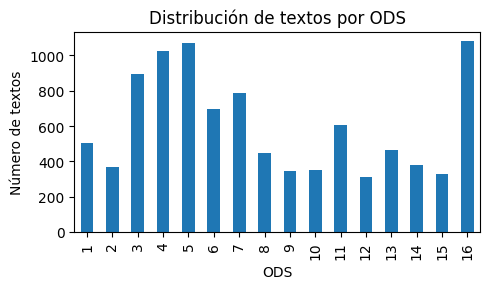

In [ ]:
plt.figure(figsize=(5, 3))
df["ODS"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("ODS")
plt.ylabel("Número de textos")
plt.title("Distribución de textos por ODS")
plt.tight_layout()
plt.show()

Se observa un desbalance de clases pero para esta iteración matendremos esta distribución

## Separación de variable independiente y variable objetivo

In [ ]:
# Separación de data  y etiquetas
X = df["textos"]
y = df["ODS"]

print("Ejemplo de X[0]:", X.iloc[0][:200], "...")
print("Ejemplo de y[0]:", y.iloc[0])

Ejemplo de X[0]: "Aprendizaje" y "educación" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organizaciones de formació ...
Ejemplo de y[0]: 4


## Split de data de entrenamiento, de test, y 1% para pruebas en futuras en streamlit


In [ ]:
# Aca se separa 20% para test, 80% entrenamiento, y del 20% del test solo se toma 1% para tener unos valores para hacer pruebas luego en la app de streamtest

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.99,
    random_state=100,
    stratify=y_temp
)


# Este 1% de los datos de test se separan y se exportan en un csv para su futuro uso en streamlit
df_val = pd.DataFrame({"texto":X_val,"ODS":y_val})
df_val.to_csv("datos_validacion_streamlit.csv",index=False,encoding="utf-8")

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test :", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test :", y_test.shape)
print("Tamaño X_val:", X_val.shape)
print("Tamaño y_val :", y_val.shape)



Tamaño X_train: (7724,)
Tamaño X_test : (1913,)
Tamaño y_train: (7724,)
Tamaño y_test : (1913,)
Tamaño X_val: (19,)
Tamaño y_val : (19,)


El uso de `stratify=y` ayuda a que la distribución de clases en train y test se parezca a la original, lo cual es útil dado que algunos ODS pueden tener menos ejemplos que otros.


# Pipiline de transformaciones reducción de la dimensionalidad y entrenamiento del modelo

#### Se usa la transformación TF-IDF, ya que esta además de la frecuencia de las palabras, tiene en cuenta su peso
#### Se escogió la técnica de reducción de dimensionalidad SVD, ya que para documentos de pocas palabras funciona mejor debido a su dispersión.
#### Y se uso  LogisticRegression por su rapidez en comparación con por ejemplo Random Forest o SVM.

In [ ]:
# Stopwords en español
spanish_stopwords = stopwords.words('spanish')

# pipeline para trasnformaciones y modelo de entrenamiento
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=spanish_stopwords, min_df=0.01, max_df=0.9)),
    ('svd', TruncatedSVD(n_components=100, random_state=100)),
    ('clf', LogisticRegression(max_iter=2000, random_state=100))
])

En el pipeline anterior, se pasan como paremetros a TfidfVectorizer las stopwords en español, descargadas anteriormente, y se mantiene por defecto su tokenizador simple. además, implementamos en TfidfVectorizer con los parámetros `min_df` y `max_df`, que controlan la frecuencia mínima y máxima de los términos en el corpus:

- min_df=0.01 → ignora términos que aparecen en menos del 1% de los documentos.

- max_df=0.90 → ignora términos que aparecen en más del 90% de los documentos.

El parametro  n_component de TruncatedSVD, determina el numero de topicos que esta reducción de dimencionalidad puede detectar, un valor muy bajo, puede llevar a un accuracy tambien bajo, y uno muy alto, pordría requerir mas recursos computacionales además de riesgo de overfitting, por eso se usa un valor estandar de 300.

El parametro max_iter en LogisticRegression, configura el número de iteraciones del modelo. Para un numero muy bajo, se podría no llegar a la convergencia y para un numero alto, como es este caso, se asegura convergencia aunque los tiempos de computo aumenten, además es mejor cuando se cuenta con features elevados con el uso de TF-IDF


## Búsqueda de Hiperparámetros

Esta búsqueda de hiperparámetros evalúa 16 combinaciones de hiperparámetros clave para optimizar el pipeline: filtros de vocabulario (`max_df` elimina términos muy frecuentes `>80-90%`, min_df elimina raros `<1% docs o 1 documento`), reducción dimensional SVD (100 o 300 componentes) y regularización de LogisticRegression (`C` bajo para más generalización, alto para mejor ajuste). Cada combinación se prueba en 3 folds de Cross-validation, seleccionando la que maximiza `f1_weighted`.

In [ ]:
param_grid = {
    "tfidf__max_df": [0.8, 0.9],
    "tfidf__min_df": [0.01, 1],
    "svd__n_components": [100, 300],
    "clf__C": [0.1, 10.0]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor score (cv):", grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Mejores hiperparámetros: {'clf__C': 10.0, 'svd__n_components': 300, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1}
Mejor score (cv): 0.86386105091626


`C=10.0` permite buen ajuste al train sin sobreajustar, `n_components=300` retiene mucha información semántica post-SVD, `max_df=0.8` elimina términos demasiado comunes (top 80%) y `min_df=1` incluye palabras raras (aparecen ≥1 doc) para capturar especificidad ODS. Esta combinación balancea expresividad con generalización, ideal para textos ODS diversos.

Nota: en la búsqueda de hiperparámetros se usó la métrica `f1_weighted` ya que calcula el promedio ponderado por el número de ejemplos de cada clase más estable si algunas ODS tienen pocos textos.

In [ ]:
#Predcciones del modelo
best_model = grid.best_estimator_
pred = best_model.predict(X_test)

#### Métricas de desempeño para cada una de las clases

In [ ]:
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification report:\n")
print(classification_report(y_test, pred))

Accuracy: 0.8651332984840564

Classification report:

              precision    recall  f1-score   support

           1       0.80      0.82      0.81       100
           2       0.81      0.68      0.74        73
           3       0.91      0.95      0.93       177
           4       0.93      0.97      0.95       203
           5       0.92      0.93      0.92       212
           6       0.93      0.88      0.91       138
           7       0.86      0.91      0.88       157
           8       0.67      0.67      0.67        88
           9       0.68      0.66      0.67        68
          10       0.67      0.59      0.63        69
          11       0.76      0.82      0.79       121
          12       0.90      0.73      0.80        62
          13       0.91      0.88      0.90        92
          14       0.90      0.84      0.87        74
          15       0.94      0.92      0.93        65
          16       0.91      0.96      0.93       214

    accuracy              

#### Matriz de confusión

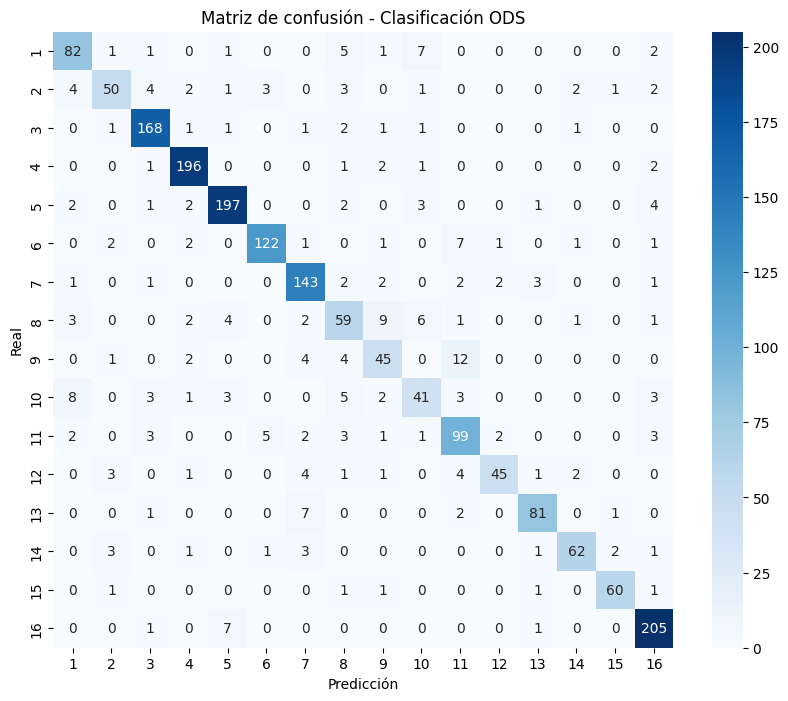

In [ ]:
cm = confusion_matrix(y_test, pred)
cm_df = pd.DataFrame(cm)

#display(cm_df)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(1,17), yticklabels=range(1,17))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Clasificación ODS")
plt.show()

Además de las métricas reportadas por `classification_report`, con la matriz de confusión se confirma que el modelo se esta comportando con un buen rendimiento en la mayoria de ODSs. La peor predicción se presenta en el ODS # 9, ya que 12 predicciones correspondientes al ODS # 9 las esta clasificando como ODS # 11.

#### Ya teniendo el modelo entrenado y sabiendo sus metricas de desempeño, exportamos este modelo para luego ser usado en la app de Streamlit


In [ ]:
joblib.dump(best_model, "modelo_texto.pkl")
print("Modelo guardado como modelo_texto.pkl")

Modelo guardado como modelo_texto.pkl


### Predicción de 3 textos no usados en el entrenamiento

In [ ]:
ejemplos_idx = np.random.choice(len(X_val), size=3, replace=False)

for i in ejemplos_idx:
    texto = X_val.iloc[i]
    verdadero = y_val.iloc[i]
    pred = best_model.predict([texto])[0]
    proba = best_model.predict_proba([texto])[0]

    print("="*80)
    print("TEXTO:")
    print(texto[:800], "..." if len(texto) > 800 else "")
    print("\nODS real:", verdadero)
    print("ODS predicho:", pred)

    # Top-5 probabilidades
    ods_labels = best_model.classes_
    top5_idx = np.argsort(proba)[-5:][::-1]
    print("Top-5 probabilidades:")
    for idx_ in top5_idx:
        print(f"  ODS {ods_labels[idx_]}: {proba[idx_]:.3f}")



En el código anterior se muestran las predicciones con 3 textos no usados en la fase de entranamiento, estos fueron escogidos al azar de X_val, que a su vez, es el 1% de los datos de test. Además, para cada unos de los 3 textos, se muestran las 5 mejores probabilidad de predicción de cada clase.

# Discusión de resultados, limitaciones y posibles mejoras

## Resultados obtenidos

El modelo basado en TF-IDF + TruncatedSVD + Regresión Logística logra un
desempeño competitivo en la tarea de clasificación de textos en los 16 ODS,
según las métricas de `precision`, `recall` y `f1-score` sobre el conjunto
de prueba. En general, los ODS con mayor cantidad de ejemplos en el dataset
presentan métricas más altas, mientras que las clases minoritarias muestran
un rendimiento más variable. El uso de probabilidades (`predict_proba`)
permite interpretar mejor la confianza del modelo y es especialmente útil
para el usuario final no técnico (UNFPA/ONU).

## Limitaciones del enfoque actual

Una primera limitación es que el modelo depende fuertemente de la calidad
del preprocesamiento y del lematizador en español; errores en esta etapa
pueden afectar la representación TF-IDF. Además, aunque TruncatedSVD reduce
la dimensionalidad, el espacio de características sigue siendo relativamente
alto y el entrenamiento requiere varios minutos en hardware convencional.
También se observa que algunas clases ODS con pocos ejemplos quedan
infra-representadas, lo que puede sesgar el modelo hacia los ODS más
frecuentes (p.e. ODS 16).

## Posibles mejoras futuras

Otra línea de trabajo podría se ajustar hiperparámetros: número de componentes
en `TruncatedSVD`, fuerza de regularización `C` en la Regresión Logística,
y límites de `min_df`/`max_df` para encontrar un mejor compromiso entre
rendimiento y tiempo de entrenamiento. También, se podrían balancear las clases y probar otras técnicas adicionales de limpieza de textos (lematización/stemming). Finalmente, sería interesante comparar
este enfoque clásico con modelos basados en embeddings (por ejemplo,
representaciones pre-entrenadas en español) y aplicar técnicas de manejo de
desbalance de clases (ponderación de clases o muestreo) para mejorar el
desempeño en los ODS menos representados.


## URL de app de Stremlit

https://proyecto2-app-jh6uqwzexabeiubssrwict.streamlit.app/